In [1]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

from ArcFace import ArcFace

In [21]:
snapshots_dir = Path("../volumes_backup/snapshots")
image_paths = list(snapshots_dir.glob("*.jpg"))
print(f"found {len(image_paths)} snapshots")

image_path = random.choice(image_paths)
print(image_path)

image = cv2.imread(str(image_path))
assert image is not None, f"failed to read {image_path}"

found 10058 snapshots
../volumes_backup/snapshots/7e1b6308-5349-45bc-bf0a-a0c2217530e9.jpg


In [22]:
arcface = ArcFace(ctx_id=-1)
faces = arcface.detect(image)
print(f"detected {len(faces)} face(s)")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/tohid/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/tohid/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/tohid/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/tohid/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/tohid/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
se

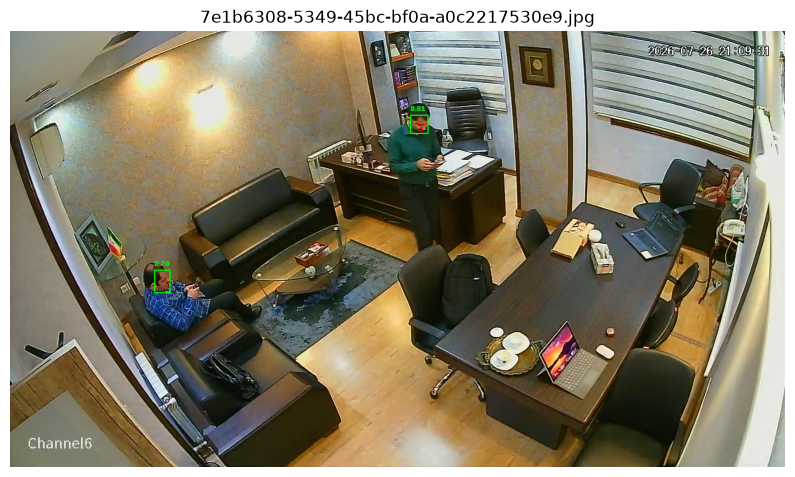

In [23]:
vis = image.copy()
for face in faces:
    x1, y1, x2, y2 = face.bbox.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        vis,
        f"{face.det_score:.2f}",
        (x1, max(y1 - 10, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
    )
    for x, y in face.kps.astype(int):
        cv2.circle(vis, (x, y), 2, (0, 0, 255), -1)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(image_path.name)
plt.show()

In [5]:
for i, face in enumerate(faces):
    print(f"face {i}: det_score={face.det_score:.3f} embedding_shape={face.embedding.shape}")